<a href="https://colab.research.google.com/github/DnlRKorn/histogram_for_sept26_hackathon/blob/main/make_hist_from_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This needs data available in ./parquet/*.parquet. If those files aren't available first run code in ./make_data.ipynb

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os
from pathlib import Path
import csv
import pyarrow.parquet as pq
import pandas as pd

In [2]:
!git clone https://github.com/DnlRKorn/histogram_for_sept26_hackathon

Cloning into 'histogram_for_sept26_hackathon'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 91 (delta 51), reused 75 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 39.79 MiB | 19.17 MiB/s, done.
Resolving deltas: 100% (51/51), done.


In [3]:
def pruneOutliers(s:pd.Series,method:str) -> pd.Series:
    if(method=="Keep_Outliers"):return s
    elif(method=="IQR"):
        (q1,q3) = s.quantile([0.25,0.75])
        iqr = abs(q3-q1)
        low_bound = q1 - iqr * 1.5
        up_bound = q3 + iqr * 1.5
        return s[(s>=low_bound) & (s<=up_bound)]
    elif(method=="Z_Score_3stdevs"):
        z_score = s.to_frame().apply(stats.zscore, ddof=1).abs().iloc[:, 0]
        return s[z_score<=3]
    elif(method=="Z_Score_5stdevs"):
        z_score = s.to_frame().apply(stats.zscore, ddof=1).abs().iloc[:, 0]
        return s[z_score<=5]
    else:
        raise ValueError(f"No outlier method {method}")

def plotHistogram(prop_vals:pd.Series, bins, log_y:bool=False, chart_title=""):
    fig, ax = plt.subplots()
    ax.set_title(chart_title)
    ax.hist(prop_vals, bins=bins,log=log_y)

def getSeriesForDataset(dataset):
    pq_path = os.path.join("histogram_for_sept26_hackathon","data","parquet",dataset+".parquet")
    pq_file = pq.ParquetFile(pq_path)
    prop_name = pq_file.schema[5].name
    arr = pq_file.read(columns=[prop_name])
    return arr.to_pandas()[prop_name]

def handleInputAndData(dataset,bin_cnt:int,log_bins:bool,log_y:bool, outlier_method:str):
    chart_title = " ".join(dataset.split('-'))

    prop_vals = getSeriesForDataset(dataset)
    prop_vals = pruneOutliers(prop_vals,outlier_method)
    if(log_bins):
        bins = np.logspace(np.log10(prop_vals.min()),np.log10(prop_vals.max()),bin_cnt)
    else: #No need to take the bins to log space, just let matplot handle the splitting
        bins = bin_cnt
    plotHistogram(prop_vals,bins,log_y,chart_title)

In [ ]:
def getPresentAbsentCnts(dataset_name):
    ingest_name,prop = dataset_name.split("-")
    with open("histogram_for_sept26_hackathon/data/prop_seen_absent_cnt.csv") as f:
        dreader = csv.DictReader(f)
        for d in dreader:
            if((d["ingest_name"]==ingest_name) and (d["prop_name"]==prop)):
                s = getSeriesForDataset(dataset_name)
                max_val = s.max()
                min_val = s.min()
                print(f"Data summary for {ingest_name} {prop}\nMinimum Val:{min_val}\nMaximum Val:{max_val}\nPresent Cnt:{d["present_cnt"]}\nAbsent Cnt:{d["absent_cnt"]}")
    df = pd.read_csv(f"histogram_for_sept26_hackathon/data/seen_absent_indiv/{dataset_name}_cnts.csv")
    return df


Data summary for diseases diseases_confidence_score
Minimum Val:2.0
Maximum Val:5.0
Present Cnt:3917
Absent Cnt:0


,spqo,present_cnt,absent_cnt
0,"('gene or gene product', 'associated with', 'n...",3917,0


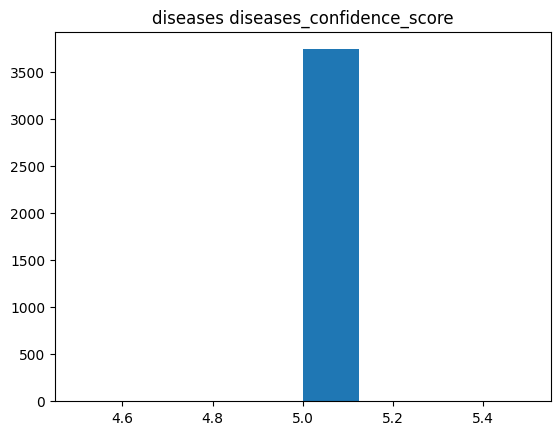

In [ ]:
# @title User Input for Histogram Generation {single-column:true}
# @markdown Forms support many types of fields.

num_bins = 20 # @param {type: "number"}
log_bin_size = False # @param {type:"boolean"}
log_bin_height = False # @param {type:"boolean"}
prune_outlier_method = "IQR" # @param ["Keep_Outliers","IQR","Z_Score_3stdevs","Z_Score_5stdevs"]
dataset = "diseases-diseases_confidence_score"  # @param ['alliance-publications', 'bindingdb-publications', 'chembl-has_confidence_score', 'chembl-publications', 'cohd-has_confidence_score', 'ctd-adjusted_p_value', 'ctd-p_value', 'ctd-publications', 'dakp-number_of_cases', 'dakp-publications', 'dgidb-dgidb_evidence_score', 'dgidb-dgidb_interaction_score', 'dgidb-publications', 'diseases-diseases_confidence_score', 'drugcentral-publications', 'gene2phenotype-gene2phenotype_confidence_category', 'gene2phenotype-publications', 'go_cam-publications', 'goa-has_evidence_of_type', 'goa-publications', 'gtopdb-publications', 'hpoa-has_evidence_of_type', 'hpoa-publications', 'intact-publications', 'pubtator-publications', 'semmeddb-publications', 'signor-has_confidence_score', 'signor-publications', 'tmkp-evidence_count', 'tmkp-publications']
# @markdown ---

#print(dataset)
pq_path = os.path.join("histogram_for_sept26_hackathon","data","parquet",dataset+".parquet")
handleInputAndData(dataset,8,log_bin_size,log_bin_height,prune_outlier_method)
getPresentAbsentCnts(dataset)

In [4]:
Source | Metric | Edge Type | N | % Missing | Min | P1 | P5 | P10 | P25 | Median | P75 | P90 | P95 | P99 | Max | % Zero | Unique Count | Mean | SD | Skewness

In [20]:
s = getSeriesForDataset("diseases-diseases_confidence_score")

In [21]:
(min, p1, p5, p10, p25, median, p75, p90, p95, p99, max) = s.quantile([0,0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])

In [35]:
def getPrecentMissing(dataset_name):
    ingest_name,prop = dataset_name.split("-")
    with open("histogram_for_sept26_hackathon/data/prop_seen_absent_cnt.csv") as f:
        dreader = csv.DictReader(f)
        for d in dreader:
            if((d["ingest_name"]==ingest_name) and (d["prop_name"]==prop)):
                s = getSeriesForDataset(dataset_name)
                return (int(d["absent_cnt"])) / (int(d["present_cnt"])+int(d["absent_cnt"]))

In [38]:
rows = []
for x in os.listdir("histogram_for_sept26_hackathon/data/parquet"):
  dataset = x.split(".")[0]
  print(x,dataset)
  source,metric = dataset.split('-')
  s = getSeriesForDataset(dataset)
  edge_type = str(s.dtype)
  n = s.shape[0]
  percent_missing = getPrecentMissing(dataset)
  (min, p1, p5, p10, p25, median, p75, p90, p95, p99, max) = s.quantile([0,0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])
  percent_zero = s[s==0].shape[0]/n
  unique_cnt = s.unique().shape[0]
  mean = s.mean()
  std = s.std()
  skew = s.skew()
  rows.append([source,metric,edge_type,n,percent_missing,min, p1, p5, p10, p25, median, p75, p90, p95, p99, max, percent_zero, unique_cnt,mean,std,skew])


hpoa-publications.parquet hpoa-publications
goa-publications.parquet goa-publications
signor-publications.parquet signor-publications
gtopdb-publications.parquet gtopdb-publications
ctd-p_value.parquet ctd-p_value
hpoa-has_evidence_of_type.parquet hpoa-has_evidence_of_type


TypeError: unsupported operand type(s) for -: 'str' and 'str'